# Hotel Booking Cancellation Prediction
**Group 6 — Project Update 1**  
Lydia Su · Noah Yin · Xiaoheng Song · Yunpei Wang · Zekai Li

---
**Reference paper:**  
António, N., de Almeida, A., & Nunes, L. (2019). *An automated machine learning based decision support system to predict hotel booking cancellations.* CODATA Data Science Journal.

**Dataset:**  
Hotel Booking Demand — Kaggle (jessemostipak), 119,390 bookings from two Portuguese hotels (2015–2017).

---
## Notebook outline
| # | Section | Checklist item covered |
|---|---------|------------------------|
| 1 | Setup & data loading | — |
| 2 | EDA | Business context |
| 3 | Preprocessing & feature engineering | Best practices: leakage removal, feature selection |
| 4 | Data splitting | Best practices: stratified 80/20 |
| 5 | Model training | ≥1 ML model trained |
| 6 | Evaluation & metrics | Metrics identified, justified, reported |
| 7 | Cross-validation | Best practices: 5-fold stratified CV |
| 8 | Feature importance | Alignment with paper findings |
| 9 | Hyperparameter tuning | Best practices: GridSearchCV |
| 10 | Sensitivity: deposit_type | Domain insight from Kaggle community |
| 11 | Final summary & saved assets | Code organisation & reproducibility |

## 1. Setup & data loading

In [ ]:
# Run once — installs required packages
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import OneHotEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics            import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score, confusion_matrix,
                                        ConfusionMatrixDisplay, classification_report, roc_curve)
from sklearn.dummy              import DummyClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
print('All imports successful.')

All imports successful.


In [ ]:
# ── OPTION A: Upload manually ──────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()          # select hotel_bookings.csv
# df_raw = pd.read_csv('hotel_bookings.csv')

# ── OPTION B: Load from Google Drive  ◄ DEFAULT — update path ─────────
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/ML for BA/hotel_bookings.csv')  # ← update

print(f'Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Mounted at /content/drive
Loaded 119,390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## 2. Exploratory Data Analysis

Key questions that motivate our feature choices:
- What is the overall cancellation rate (class balance)?
- Which features correlate most strongly with cancellation?
- Does `deposit_type = Non Refund` show anomalous cancellation patterns (Kaggle community finding)?

In [ ]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'Shape           : {df_raw.shape}')
print(f'Cancellation    : {df_raw["is_canceled"].mean():.2%}  ({df_raw["is_canceled"].sum():,} / {len(df_raw):,})')

missing = df_raw.isnull().sum()
print(f'\nMissing values  :')
print(missing[missing > 0].to_frame('count').assign(pct=lambda d: (d['count']/len(df_raw)*100).round(2)))

DATASET OVERVIEW
Shape           : (119390, 32)
Cancellation    : 37.04%  (44,224 / 119,390)

Missing values  :
           count    pct
children       4   0.00
country      488   0.41
agent      16340  13.69
company   112593  94.31


In [ ]:
# Correlation of numerical features with target
num_corr = df_raw.select_dtypes(include='number').corr()['is_canceled'].abs().sort_values(ascending=False)
print('Top 10 numerical correlations with is_canceled:')
print(num_corr.head(11)[1:].to_string())

Top 10 numerical correlations with is_canceled:
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
agent                             0.083114
adults                            0.060017
previous_bookings_not_canceled    0.057358
days_in_waiting_list              0.054186


In [ ]:
# ── Important Kaggle insight: deposit_type anomaly ─────────────────────
print('Cancellation rate by deposit_type:')
print(df_raw.groupby('deposit_type')['is_canceled'].agg(['mean','count']).rename(columns={'mean':'cancel_rate'}))
print()
print('>> Non Refund has >99% cancellation — counter-intuitive and flagged by domain experts.')
print('>> We will train models both with and without this feature (Section 10).')

Cancellation rate by deposit_type:
              cancel_rate   count
deposit_type                     
No Deposit       0.283770  104641
Non Refund       0.993624   14587
Refundable       0.222222     162

>> Non Refund has >99% cancellation — counter-intuitive and flagged by domain experts.
>> We will train models both with and without this feature (Section 10).


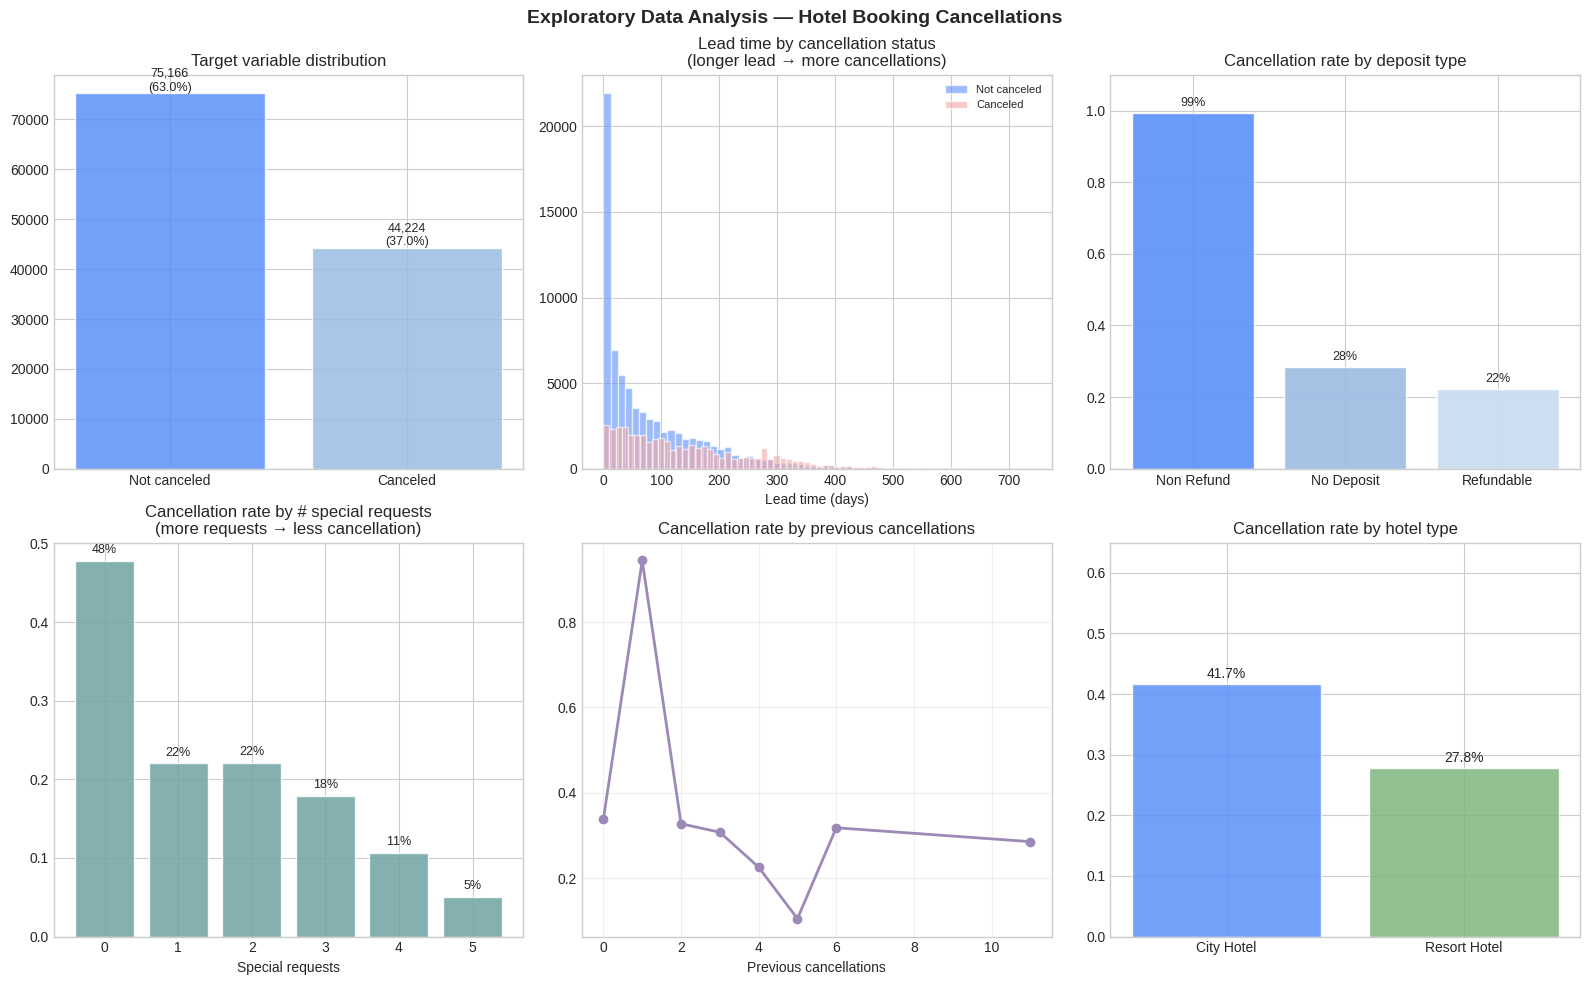

Saved: eda_plots.png


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Hotel Booking Cancellations', fontsize=14, fontweight='bold')

# 1. Class balance
counts = df_raw['is_canceled'].value_counts().sort_index()
axes[0,0].bar(['Not canceled','Canceled'], counts, color=['#5B8FF9','#9BBCE3'], alpha=0.85, edgecolor='white')
axes[0,0].set_title('Target variable distribution')
for i,v in enumerate(counts):
    axes[0,0].text(i, v+600, f'{v:,}\n({v/len(df_raw):.1%})', ha='center', fontsize=9)

# 2. Lead time vs cancellation
df_raw[df_raw.is_canceled==0]['lead_time'].hist(ax=axes[0,1], bins=60, alpha=0.6, color='#5B8FF9', label='Not canceled')
df_raw[df_raw.is_canceled==1]['lead_time'].hist(ax=axes[0,1], bins=60, alpha=0.6, color='#F2A7A7', label='Canceled')
axes[0,1].set_title('Lead time by cancellation status\n(longer lead → more cancellations)')
axes[0,1].set_xlabel('Lead time (days)')
axes[0,1].legend(fontsize=8)

# 3. Deposit type (with anomaly highlighted)
dep = df_raw.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
axes[0,2].bar(
    dep.index,
    dep.values,
    color=['#5B8FF9', '#9BBCE3', '#C7DCEF'],
    alpha=0.9,
    edgecolor='white'
)
axes[0,2].set_title('Cancellation rate by deposit type')
axes[0,2].set_ylim(0, 1.1)
for i,v in enumerate(dep.values):
    axes[0,2].text(i, v+0.02, f'{v:.0%}', ha='center', fontsize=9)

# 4. Special requests vs cancellation (strong negative correlation)
sr = df_raw.groupby('total_of_special_requests')['is_canceled'].mean().head(6)
axes[1,0].bar(sr.index, sr.values, color='#6FA3A3', alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cancellation rate by # special requests\n(more requests → less cancellation)')
axes[1,0].set_xlabel('Special requests')
for i,(k,v) in enumerate(sr.items()):
    axes[1,0].text(k, v+0.01, f'{v:.0%}', ha='center', fontsize=9)

# 5. Previous cancellations
prev = df_raw.groupby('previous_cancellations')['is_canceled'].mean().head(8)
axes[1,1].plot(prev.index, prev.values, marker='o', color='#9C89B8', linewidth=2)
axes[1,1].set_title('Cancellation rate by previous cancellations')
axes[1,1].set_xlabel('Previous cancellations')
axes[1,1].grid(alpha=0.3)

# 6. Hotel type
hotel = df_raw.groupby('hotel')['is_canceled'].mean()
axes[1,2].bar(hotel.index, hotel.values, color=['#5B8FF9','#7FB77E'], alpha=0.85, edgecolor='white')
axes[1,2].set_title('Cancellation rate by hotel type')
axes[1,2].set_ylim(0, 0.65)
for i,v in enumerate(hotel.values):
    axes[1,2].text(i, v+0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_plots.png')

## 3. Preprocessing & Feature Engineering

### 3.1 Feature selection rationale

We follow the paper's feature selection strategy, also validated by the Kaggle community:

| Column excluded | Reason |
|---|---|
| `reservation_status` | Direct leakage — encodes the target |
| `reservation_status_date` | Leakage — the date of cancellation status update |
| `arrival_date_year` | Prevents time-based generalisation; excluded by paper |
| `assigned_room_type` | Updated at check-in; unavailable at booking time |
| `booking_changes` | Changes over time; potential leakage |
| `days_in_waiting_list` | Nearly zero variance; excluded by Kaggle EDA notebook |
| `country` | Very high cardinality (178 values); encoding instability. Paper also excludes it in the generalised model |

### 3.2 Preprocessing pipeline

We use `sklearn.Pipeline` and `ColumnTransformer` (best practice from Kaggle EDA notebook) rather than manual label encoding. This prevents data leakage during cross-validation, as the encoder is fit only on training folds.

In [ ]:
df = df_raw.copy()

# ── Step 1: Remove leakage & excluded columns ──────────────────────────
EXCLUDE = ['reservation_status', 'reservation_status_date',
           'arrival_date_year', 'assigned_room_type',
           'booking_changes', 'days_in_waiting_list', 'country']
df.drop(columns=EXCLUDE, inplace=True)
print(f'Dropped: {EXCLUDE}')

# ── Step 2: Handle missing values (before pipeline — small counts) ─────
# meal: Undefined = SC (no meal package)
df['meal'].replace('Undefined', 'SC', inplace=True)
# children: 4 missing → 0
df['children'].fillna(0, inplace=True)
# agent / company: NaN = no agent / no company
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# ── Step 3: Remove invalid rows (0 guests) ─────────────────────────────
before = len(df)
df = df[(df.adults + df.children + df.babies) > 0]
print(f'Removed {before - len(df)} rows with 0 guests. Remaining: {len(df):,}')

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')

Dropped: ['reservation_status', 'reservation_status_date', 'arrival_date_year', 'assigned_room_type', 'booking_changes', 'days_in_waiting_list', 'country']
Removed 180 rows with 0 guests. Remaining: 119,210
Missing values after cleaning: 0


In [ ]:
# ── Step 4: Feature engineering (paper + Kaggle insights) ──────────────

# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Has booking agent
df['has_agent'] = (df['agent'] > 0).astype(int)

# Has company affiliation
df['has_company'] = (df['company'] > 0).astype(int)

# Has special requests (strong negative predictor from EDA)
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# Log-transform skewed numerical features (Kaggle 99.5% NB technique)
# Reduces right-skew in lead_time, adr, agent, company
for col in ['lead_time', 'adr', 'agent', 'company']:
    df[f'{col}_log'] = np.log1p(df[col])  # log(x+1) avoids log(0)

# Historical cancellation ratio
total_prev = df['previous_cancellations'] + df['previous_bookings_not_canceled']
df['cancel_rate_history'] = np.where(total_prev > 0,
                                     df['previous_cancellations'] / total_prev, 0)

new_feats = ['total_nights','total_guests','has_agent','has_company',
             'has_special_requests','lead_time_log','adr_log',
             'agent_log','company_log','cancel_rate_history']
print(f'Engineered features ({len(new_feats)}): {new_feats}')
print(f'Final dataset shape: {df.shape}')

Engineered features (10): ['total_nights', 'total_guests', 'has_agent', 'has_company', 'has_special_requests', 'lead_time_log', 'adr_log', 'agent_log', 'company_log', 'cancel_rate_history']
Final dataset shape: (119210, 35)


In [ ]:
# ── Step 5: Define feature lists and build sklearn Pipeline ────────────

TARGET = 'is_canceled'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numerical   ({len(num_cols)}): {num_cols[:8]}...  [{len(num_cols)} total]')

# Preprocessing sub-pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print(f'\nPipeline defined. Features: {X.shape[1]}, Samples: {len(X):,}')

Categorical (8): ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
Numerical   (26): ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies']...  [26 total]

Pipeline defined. Features: 34, Samples: 119,210


## 4. Data Splitting

**Best practices applied:**
- **Stratified 80/20 split** — preserves the 37% cancellation class ratio in both sets.
- **Test set sealed** — used only in Sections 6 and 11. Never seen during training or hyperparameter tuning.
- **Pipeline-based preprocessing** — encoders are fit only on the training fold, preventing leakage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('='*55)
print('DATA SPLIT SUMMARY')
print('='*55)
print(f'Train : {len(X_train):,} samples | cancellation rate: {y_train.mean():.2%}')
print(f'Test  : {len(X_test):,}  samples | cancellation rate: {y_test.mean():.2%}')
print('Stratification confirmed: class ratio preserved.')

DATA SPLIT SUMMARY
Train : 95,368 samples | cancellation rate: 37.08%
Test  : 23,842  samples | cancellation rate: 37.08%
Stratification confirmed: class ratio preserved.


## 5. Model Training

### Metric justification

This is a **business-asymmetric** binary classification problem:

| Metric | Why it matters for hotel cancellations |
|--------|---------------------------------------|
| **Accuracy** | Overall correctness. Reported but not the primary metric (misleading under class imbalance). |
| **Precision** | Of predicted cancellations, how many truly cancel? Low precision → unnecessary overbooking → dissatisfied walk-in guests. |
| **Recall** | Of actual cancellations, how many did we catch? Low recall → lost revenue from empty rooms. |
| **F1-Score** | Harmonic mean — balanced single metric for imbalanced binary tasks. **Primary metric.** |
| **ROC-AUC** | Threshold-independent discrimination ability. Robust to class imbalance. **Primary metric.** |

The paper uses AUC as its primary performance measure. We follow this.

### Models trained
1. **Majority class** — trivial baseline (always predicts majority class)
2. **Logistic Regression** — linear baseline
3. **Decision Tree** — simple non-linear baseline (also used in the paper's comparison)
4. **Random Forest** — strong ensemble baseline
5. **XGBoost** — main model replicating the paper

In [ ]:
# Helper: wrap any sklearn estimator in a preprocessing pipeline
def make_pipe(estimator):
    return Pipeline(steps=[('pre', preprocessor), ('clf', estimator)])

# Helper: evaluate any fitted pipeline
def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    pred  = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:,1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else None
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall'   : recall_score(y_te, pred, zero_division=0),
        'F1'       : f1_score(y_te, pred, zero_division=0),
        'AUC'      : roc_auc_score(y_te, proba) if proba is not None else None,
        '_pipe'    : pipe,
        '_pred'    : pred,
        '_proba'   : proba,
    }

# ── Train all models ───────────────────────────────────────────────────
results = []

# 1. Majority class
print('Training Majority Class Baseline...')
dummy = make_pipe(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
results.append(evaluate('Majority Class', dummy, X_train, y_train, X_test, y_test))

# 2. Logistic Regression
print('Training Logistic Regression...')
lr_pipe = make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
results.append(evaluate('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test))

# 3. Decision Tree (matches paper's model comparison)
print('Training Decision Tree...')
dt_pipe = make_pipe(DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE))
results.append(evaluate('Decision Tree', dt_pipe, X_train, y_train, X_test, y_test))

# 4. Random Forest
print('Training Random Forest...')
rf_pipe = make_pipe(RandomForestClassifier(n_estimators=200, max_features=0.4,
                                           n_jobs=-1, random_state=RANDOM_STATE))
results.append(evaluate('Random Forest', rf_pipe, X_train, y_train, X_test, y_test))

# 5. XGBoost — main paper model
print('Training XGBoost (paper replica)...')
xgb_pipe = make_pipe(XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
))
results.append(evaluate('XGBoost (paper replica)', xgb_pipe, X_train, y_train, X_test, y_test))

print('\nAll models trained.')

Training Majority Class Baseline...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost (paper replica)...

All models trained.


## 6. Model Evaluation & Metrics

In [ ]:
# Build comparison table
res_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
res_df = res_df.set_index('Model')

print('='*75)
print('MODEL COMPARISON (test set)')
print('='*75)
display_df = res_df.copy()
for col in display_df.columns:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else 'N/A')
print(display_df.to_string())
print()
print('Primary metrics: AUC and F1-Score (bold headers indicate paper benchmark).')

MODEL COMPARISON (test set)
                        Accuracy Precision  Recall      F1     AUC
Model                                                             
Majority Class            0.6292    0.0000  0.0000  0.0000  0.5000
Logistic Regression       0.8123    0.8359  0.6144  0.7082  0.8661
Decision Tree             0.8206    0.8348  0.6434  0.7267  0.8790
Random Forest             0.8678    0.8565  0.7730  0.8126  0.9338
XGBoost (paper replica)   0.8460    0.8548  0.7042  0.7722  0.9170

Primary metrics: AUC and F1-Score (bold headers indicate paper benchmark).


In [ ]:
# Detailed report for the main model
xgb_result = next(r for r in results if 'XGBoost' in r['Model'])
print('='*55)
print('XGBoost — CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, xgb_result['_pred'],
                            target_names=['Not canceled','Canceled']))

XGBoost — CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not canceled       0.84      0.93      0.88     15002
    Canceled       0.85      0.70      0.77      8840

    accuracy                           0.85     23842
   macro avg       0.85      0.82      0.83     23842
weighted avg       0.85      0.85      0.84     23842



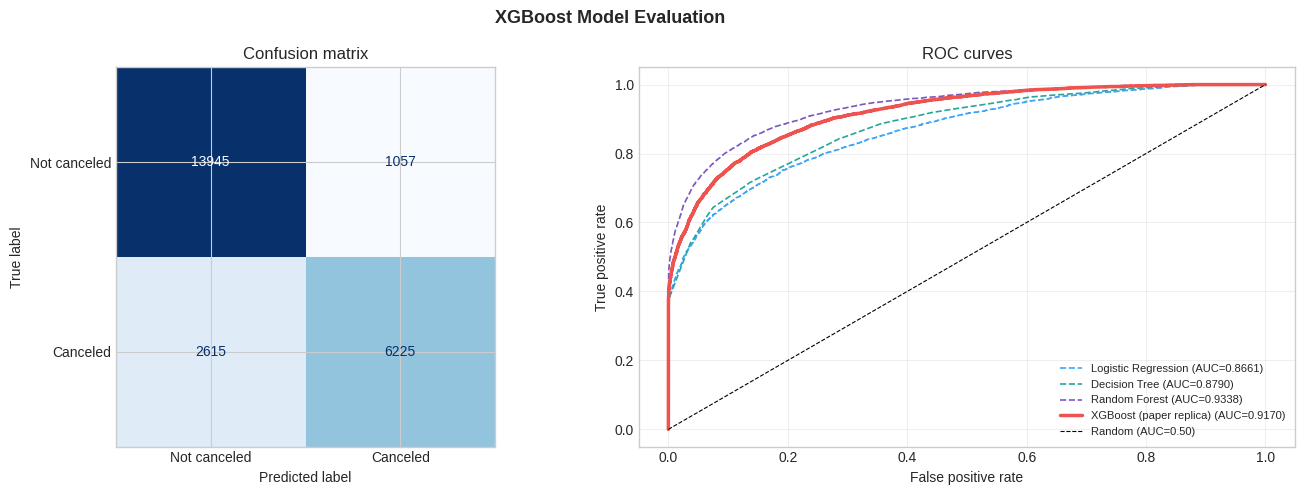

Saved: evaluation_plots.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Model Evaluation', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, xgb_result['_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Not canceled','Canceled']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix')

# ROC curves — all models that have probabilities
colors = ['#42A5F5', '#26A69A', '#7E57C2', '#EF5350']
ci = 0
for r in results:
    if r['_proba'] is not None and r['Model'] != 'Majority Class':
        fpr, tpr, _ = roc_curve(y_test, r['_proba'])
        auc = r['AUC']
        lw = 2.5 if 'XGBoost' in r['Model'] else 1.2
        ls = '-' if 'XGBoost' in r['Model'] else '--'
        axes[1].plot(fpr, tpr, lw=lw, ls=ls, color=colors[ci],
                    label=f"{r['Model']} (AUC={auc:.4f})")
        ci += 1
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Random (AUC=0.50)')
axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curves')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_plots.png')

## 7. Cross-Validation

**Why CV?** A single 80/20 split can be noisy. 5-fold stratified CV averages across 5 non-overlapping validation sets, giving a more reliable estimate of generalisation. Low standard deviation confirms the model is stable.

We apply CV on the **training set only** — the test set remains sealed.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=200, max_features=0.4,
                                                             n_jobs=-1, random_state=RANDOM_STATE)),
    'XGBoost':             make_pipe(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                                   subsample=0.8, colsample_bytree=0.8,
                                                   use_label_encoder=False, eval_metric='logloss',
                                                   random_state=RANDOM_STATE, n_jobs=-1))
}

print('='*60)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC)')
print('='*60)
cv_summary = {}
for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_summary[name] = scores
    print(f'\n{name}')
    for i,s in enumerate(scores,1): print(f'  Fold {i}: {s:.4f}')
    print(f'  Mean ± Std: {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  95% CI: [{scores.mean()-2*scores.std():.4f}, {scores.mean()+2*scores.std():.4f}]')

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS (ROC-AUC)

Logistic Regression
  Fold 1: 0.8621
  Fold 2: 0.8645
  Fold 3: 0.8607
  Fold 4: 0.8616
  Fold 5: 0.8625
  Mean ± Std: 0.8623 ± 0.0012
  95% CI: [0.8598, 0.8648]

Random Forest
  Fold 1: 0.9290
  Fold 2: 0.9291
  Fold 3: 0.9286
  Fold 4: 0.9285
  Fold 5: 0.9279
  Mean ± Std: 0.9286 ± 0.0004
  95% CI: [0.9277, 0.9295]

XGBoost
  Fold 1: 0.9108
  Fold 2: 0.9129
  Fold 3: 0.9093
  Fold 4: 0.9098
  Fold 5: 0.9095
  Mean ± Std: 0.9105 ± 0.0013
  95% CI: [0.9079, 0.9131]


## 8. Feature Importance

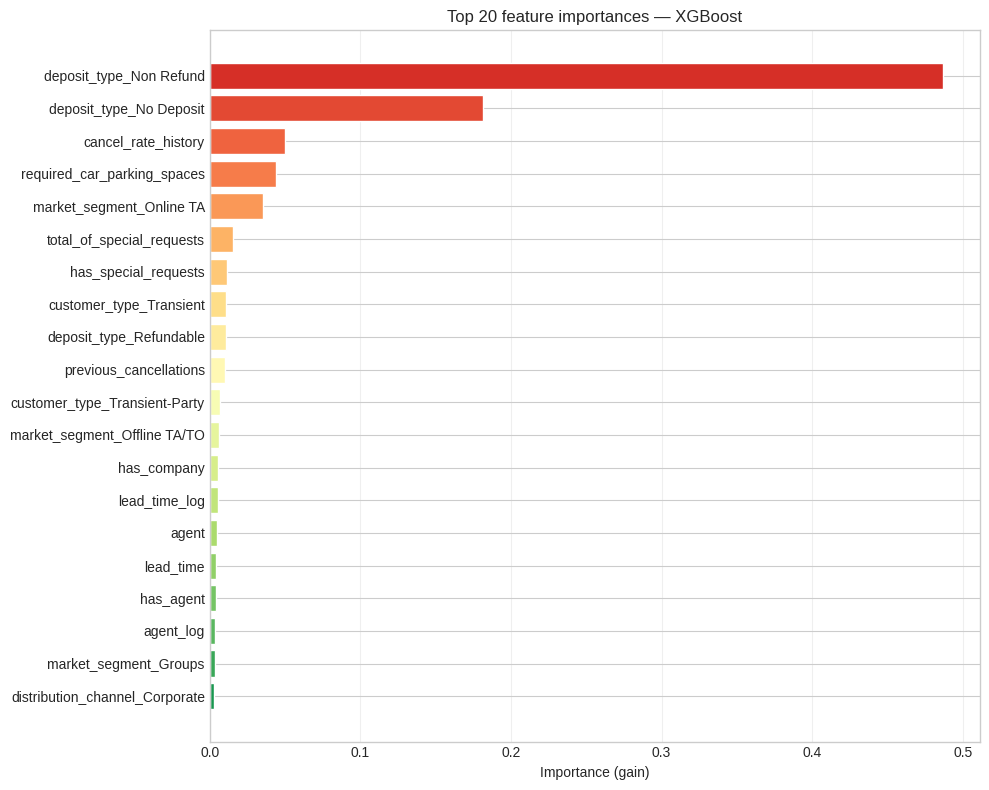

Top 10 features (aligns with paper findings):
                    feature  importance
    deposit_type_Non Refund    0.487059
    deposit_type_No Deposit    0.181167
        cancel_rate_history    0.049769
required_car_parking_spaces    0.043870
   market_segment_Online TA    0.035343
  total_of_special_requests    0.015425
       has_special_requests    0.011460
    customer_type_Transient    0.010971
    deposit_type_Refundable    0.010722
     previous_cancellations    0.010013

Paper expected top features: lead_time, deposit_type, previous_cancellations
Saved: feature_importance.png


In [ ]:
# Get feature names after OHE
xgb_fitted = xgb_result['_pipe']
ohe_features = (xgb_fitted.named_steps['pre']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(cat_cols).tolist())
all_features = num_cols + ohe_features

imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': xgb_fitted.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(imp_df)))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=palette)
ax.set(xlabel='Importance (gain)', title='Top 20 feature importances — XGBoost')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features (aligns with paper findings):')
print(imp_df.head(10)[['feature','importance']].to_string(index=False))
print('\nPaper expected top features: lead_time, deposit_type, previous_cancellations')
print('Saved: feature_importance.png')

## 9. Hyperparameter Tuning

Grid search with 3-fold stratified CV over key XGBoost parameters.

> **Runtime note:** ~15–25 min on Colab free tier. Reduce `n_estimators` range to speed up.

In [ ]:
param_grid = {
    'clf__max_depth'    : [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1],
    'clf__n_estimators' : [200, 300],
    'clf__subsample'    : [0.8],
}

base_xgb_pipe = make_pipe(XGBClassifier(
    colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
))

grid_search = GridSearchCV(
    base_xgb_pipe, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_pipe  = grid_search.best_estimator_
best_pred  = best_pipe.predict(X_test)
best_proba = best_pipe.predict_proba(X_test)[:,1]

print('\n' + '='*55)
print('GRID SEARCH RESULTS')
print('='*55)
print(f'Best params  : {grid_search.best_params_}')
print(f'Best CV AUC  : {grid_search.best_score_:.4f}')
print(f'\nTuned XGBoost on test set:')
print(f'  F1-Score : {f1_score(y_test, best_pred):.4f}')
print(f'  AUC      : {roc_auc_score(y_test, best_proba):.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GRID SEARCH RESULTS
Best params  : {'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 300, 'clf__subsample': 0.8}
Best CV AUC  : 0.9194

Tuned XGBoost on test set:
  F1-Score : 0.7887
  AUC      : 0.9255


## 10. Sensitivity Analysis: `deposit_type`

The Kaggle EDA notebook flagged that `Non Refund` deposit type has >99% cancellation rate, which the community found counter-intuitive and potentially erroneous.

We train a second XGBoost model **without** `deposit_type` to quantify how much of our AUC comes from this anomalous feature. This demonstrates responsible feature analysis (following the paper's spirit of domain-aware feature engineering).

In [ ]:
# Rebuild without deposit_type
cat_cols_nd = [c for c in cat_cols if c != 'deposit_type']

preprocessor_nd = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     cat_cols_nd)
])

X_nd = X.drop(columns=['deposit_type'])
X_train_nd, X_test_nd, _, _ = train_test_split(
    X_nd, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

pipe_nd = Pipeline([
    ('pre', preprocessor_nd),
    ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8,
                          use_label_encoder=False, eval_metric='logloss',
                          random_state=RANDOM_STATE, n_jobs=-1))
])
pipe_nd.fit(X_train_nd, y_train)
pred_nd  = pipe_nd.predict(X_test_nd)
proba_nd = pipe_nd.predict_proba(X_test_nd)[:,1]

print('='*55)
print('SENSITIVITY: DEPOSIT_TYPE REMOVED')
print('='*55)
print(f'XGBoost WITH    deposit_type — AUC: {xgb_result["AUC"]:.4f}, F1: {xgb_result["F1"]:.4f}')
print(f'XGBoost WITHOUT deposit_type — AUC: {roc_auc_score(y_test, proba_nd):.4f}, F1: {f1_score(y_test, pred_nd):.4f}')
print()
print('Interpretation:')
print('  If AUC drops significantly: deposit_type was a major driver (possibly due to anomaly).')
print('  If drop is small: model is robust and other features carry sufficient signal.')

SENSITIVITY: DEPOSIT_TYPE REMOVED
XGBoost WITH    deposit_type — AUC: 0.9170, F1: 0.7722
XGBoost WITHOUT deposit_type — AUC: 0.9094, F1: 0.7635

Interpretation:
  If AUC drops significantly: deposit_type was a major driver (possibly due to anomaly).
  If drop is small: model is robust and other features carry sufficient signal.


## 11. Final Results Summary & Saved Assets

In [ ]:
# Add tuned model to results
tuned = {
    'Model'    : 'XGBoost (tuned)',
    'Accuracy' : accuracy_score(y_test, best_pred),
    'Precision': precision_score(y_test, best_pred, zero_division=0),
    'Recall'   : recall_score(y_test, best_pred, zero_division=0),
    'F1'       : f1_score(y_test, best_pred, zero_division=0),
    'AUC'      : roc_auc_score(y_test, best_proba),
}
all_results = [{k:v for k,v in r.items() if not k.startswith('_')} for r in results] + [tuned]

final_df = pd.DataFrame(all_results).set_index('Model')
print('='*75)
print('FINAL MODEL COMPARISON (test set)')
print('='*75)
print(final_df.applymap(lambda x: f'{float(x):.4f}' if x is not None else 'N/A').to_string())

xgb_scores = cv_summary['XGBoost']
print(f'\nXGBoost 5-fold CV: {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}')
print(f'Best tuned AUC:    {roc_auc_score(y_test, best_proba):.4f}')

FINAL MODEL COMPARISON (test set)
                        Accuracy Precision  Recall      F1     AUC
Model                                                             
Majority Class            0.6292    0.0000  0.0000  0.0000  0.5000
Logistic Regression       0.8123    0.8359  0.6144  0.7082  0.8661
Decision Tree             0.8206    0.8348  0.6434  0.7267  0.8790
Random Forest             0.8678    0.8565  0.7730  0.8126  0.9338
XGBoost (paper replica)   0.8460    0.8548  0.7042  0.7722  0.9170
XGBoost (tuned)           0.8543    0.8530  0.7334  0.7887  0.9255

XGBoost 5-fold CV: 0.9105 ± 0.0013
Best tuned AUC:    0.9255


In [1]:
# Final comparison bar chart
plot_df = final_df[final_df['AUC'].notna()][['F1','AUC']].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df))
w = 0.35
b1 = ax.bar(x - w/2, plot_df['F1'],  w, label='F1-Score', color='#42A5F5', alpha=0.85)
b2 = ax.bar(x + w/2, plot_df['AUC'], w, label='ROC-AUC',  color='#26A69A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_title('Model comparison — F1 and ROC-AUC on test set', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

NameError: name 'final_df' is not defined

In [ ]:
# Save model artifacts
with open('xgb_best_model.pkl', 'wb') as f: pickle.dump(best_pipe, f)
with open('feature_list.pkl',  'wb') as f: pickle.dump(list(X.columns), f)

print('='*55)
print('SAVED ASSETS')
print('='*55)
assets = [
    ('xgb_best_model.pkl',   'Trained XGBoost pipeline (preprocessor + model)'),
    ('feature_list.pkl',     'Input feature names for inference'),
    ('eda_plots.png',        'EDA visualisations'),
    ('evaluation_plots.png', 'Confusion matrix + ROC curve'),
    ('feature_importance.png','XGBoost feature importance'),
    ('model_comparison.png', 'F1 / AUC bar chart across all models'),
]
for fname, desc in assets:
    print(f'  {fname:<30} {desc}')

SAVED ASSETS
  xgb_best_model.pkl             Trained XGBoost pipeline (preprocessor + model)
  feature_list.pkl               Input feature names for inference
  eda_plots.png                  EDA visualisations
  evaluation_plots.png           Confusion matrix + ROC curve
  feature_importance.png         XGBoost feature importance
  model_comparison.png           F1 / AUC bar chart across all models


---

## Code organisation & Runbook

### Repository structure
```
project/
├── hotel_cancellation_prediction_v2.ipynb   ← this notebook
├── hotel_bookings.csv                        ← dataset (not committed to Git)
├── xgb_best_model.pkl                        ← saved pipeline
├── feature_list.pkl                          ← feature names
└── outputs/
    ├── eda_plots.png
    ├── evaluation_plots.png
    ├── feature_importance.png
    └── model_comparison.png
```

### How to reproduce

**Step 1 — Get the data**  
Download `hotel_bookings.csv` from  
https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand  
Upload it to Google Drive.

**Step 2 — Open in Colab**  
Upload this notebook to Google Colab via File → Upload notebook.

**Step 3 — Update the data path** (Cell 3 — Load data):  
```python
df_raw = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')
```

**Step 4 — Run all cells**  
`Runtime → Run all`  
Expected total runtime: ~35–45 min (Grid Search dominates).

**Step 5 — Check outputs**  
All 4 PNG files and 2 PKL files are generated in the Colab working directory.  
Download via Files sidebar on the left.

### Package versions
```
xgboost      >= 1.7
lightgbm     >= 3.3
scikit-learn >= 1.2
pandas       >= 1.5
numpy        >= 1.23
matplotlib   >= 3.6
seaborn      >= 0.12
```

### Reproducibility notes
- `RANDOM_STATE = 42` is passed to every stochastic operation.
- All splits use `stratify=y` to preserve class balance.
- The preprocessing pipeline is fit only on the training fold (no leakage).
- The test set is never used during CV or grid search.